In [1]:
import pandas as pd
import os
import json
from utils.eda_utils import EDAUtils, FeatureEngineering, DataCleaningUtils
from utils.ml_utils_v2 import RegressionAnalysis, FeaturePredictiveEvaluator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib
import time

In [2]:
eda_utils = EDAUtils()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [3]:
# Enable automatic reloading of modules before executing user code (useful during development)
%load_ext autoreload
%autoreload 2

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "country_panel_data")
PARQUET_PATH = os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars.parquet")
JSON_METADATA_PATH =os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars_metadata.json")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")

In [5]:
# Load dataframe
df = pd.read_parquet(PARQUET_PATH)
df.head()

,iso_alpha_3,year,country_name,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_gdp_per_capita_ppp_current,cap_population,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,...,inc_has_framework_law,inc_n_climate_laws,inc_n_policies_total,inc_n_sectors_covered,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout,con_edgar_ghg_mt
0,AFG,2002,Afghanistan,3.825701e+09,338.139974,926.507941,21378117.0,0.220,0.084,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.774572
1,AFG,2003,Afghanistan,4.520947e+09,346.071627,966.962032,22733049.0,0.227,0.086,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.403565
2,AFG,2004,Afghanistan,5.224897e+09,338.637274,971.633503,23560654.0,0.238,0.091,0.931,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.539336
3,AFG,2005,Afghanistan,6.203257e+09,363.640141,1076.087353,24404567.0,0.319,0.113,0.942,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.690913
4,AFG,2006,Afghanistan,6.971758e+09,367.758312,1121.834471,25424094.0,0.373,0.199,0.955,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.884498


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 60 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   iso_alpha_3                                2856 non-null   str    
 1   year                                       2856 non-null   int64  
 2   country_name                               2856 non-null   str    
 3   cap_gdp_current_usd                        2856 non-null   float64
 4   cap_gdp_per_capita_constant_2015           2856 non-null   float64
 5   cap_gdp_per_capita_ppp_current             2856 non-null   float64
 6   cap_population                             2856 non-null   float64
 7   cap_electoral_democracy_idx                2856 non-null   float64
 8   cap_liberal_democracy_idx                  2856 non-null   float64
 9   cap_corruption_idx                         2856 non-null   float64
 10  cap_rule_of_law_idx                

In [7]:
# Load metadata
with open(JSON_METADATA_PATH, "r") as file:
    df_metadata = json.load(file) 
df_metadata.keys()

dict_keys(['configuration', 'dimensions', 'zero_filled_variables'])

In [8]:
# Obtain emission fields
emission_fields = df_metadata["dimensions"]["EMISSIONS"]
emission_fields

['con_co2_incl_luc_mt',
 'con_co2_intensity',
 'con_co2_mt',
 'con_co2_per_capita',
 'con_edgar_ghg_mt',
 'con_edgar_ghg_gg',
 'con_ghg_per_capita',
 'con_methane_mt',
 'con_nitrous_oxide_mt',
 'con_share_global_co2_pct',
 'con_total_emissions',
 'con_total_ghg_mt']

In [10]:
emission_fields = [field for field in emission_fields if field in df.columns]
df[emission_fields]

,con_edgar_ghg_mt
0,25.774572
1,26.403565
2,26.539336
3,26.690913
4,26.884498
...,...
2851,43.275300
2852,41.713705
2853,40.038006
2854,42.393929


In [11]:
# define target variable
target_var = "con_edgar_ghg_mt"

## Data prep

### Filter data to avoid leakage

In [12]:
emission_fields.remove(target_var)
emission_fields

[]

In [13]:
df_filtered = df.drop(columns=emission_fields + ["country_name"])
df_filtered.columns

Index(['iso_alpha_3', 'year', 'cap_gdp_current_usd',
       'cap_gdp_per_capita_constant_2015', 'cap_gdp_per_capita_ppp_current',
       'cap_population', 'cap_electoral_democracy_idx',
       'cap_liberal_democracy_idx', 'cap_corruption_idx',
       'cap_rule_of_law_idx', 'cap_accountability_idx',
       'cap_civil_liberties_idx', 'cap_control_corruption',
       'cap_govt_effectiveness', 'cap_political_stability',
       'cap_regulatory_quality', 'cap_rule_of_law', 'cap_voice_accountability',
       'con_agricultural_land_pct', 'con_bioenergy', 'con_coal', 'con_demand',
       'con_demand_per_capita', 'con_electricity_access_pct',
       'con_electricity_generation_twh', 'con_energy_per_capita_kwh',
       'con_forest_area_pct', 'con_fossil_share_elec_pct', 'con_gas',
       'con_gas_and_other_fossil', 'con_hydro',
       'con_hydro,_bioenergy_and_other_renewables', 'con_net_elec_imports_twh',
       'con_nuclear', 'con_other_fossil', 'con_population',
       'con_primary_energy_twh'

### Filter some redoundant variables

In [14]:
redoundant_fields = [
    "cap_gdp_per_capita_constant_2015",
    "cap_gdp_current_usd",
    "con_population",
    "cap_population",
    "cap_electoral_democracy_idx",
    "cap_accountability_idx",
    "con_electricity_generation_twh",
    "con_total_generation",
    "con_gas_and_other_fossil",
    "con_hydro,_bioenergy_and_other_renewables",
    "con_ndgain_readiness",
    "inc_n_policies_total",
    "inc_n_sectors_covered",
]

In [15]:
df_filtered = df_filtered.drop(columns=redoundant_fields)

### Fix Skewness

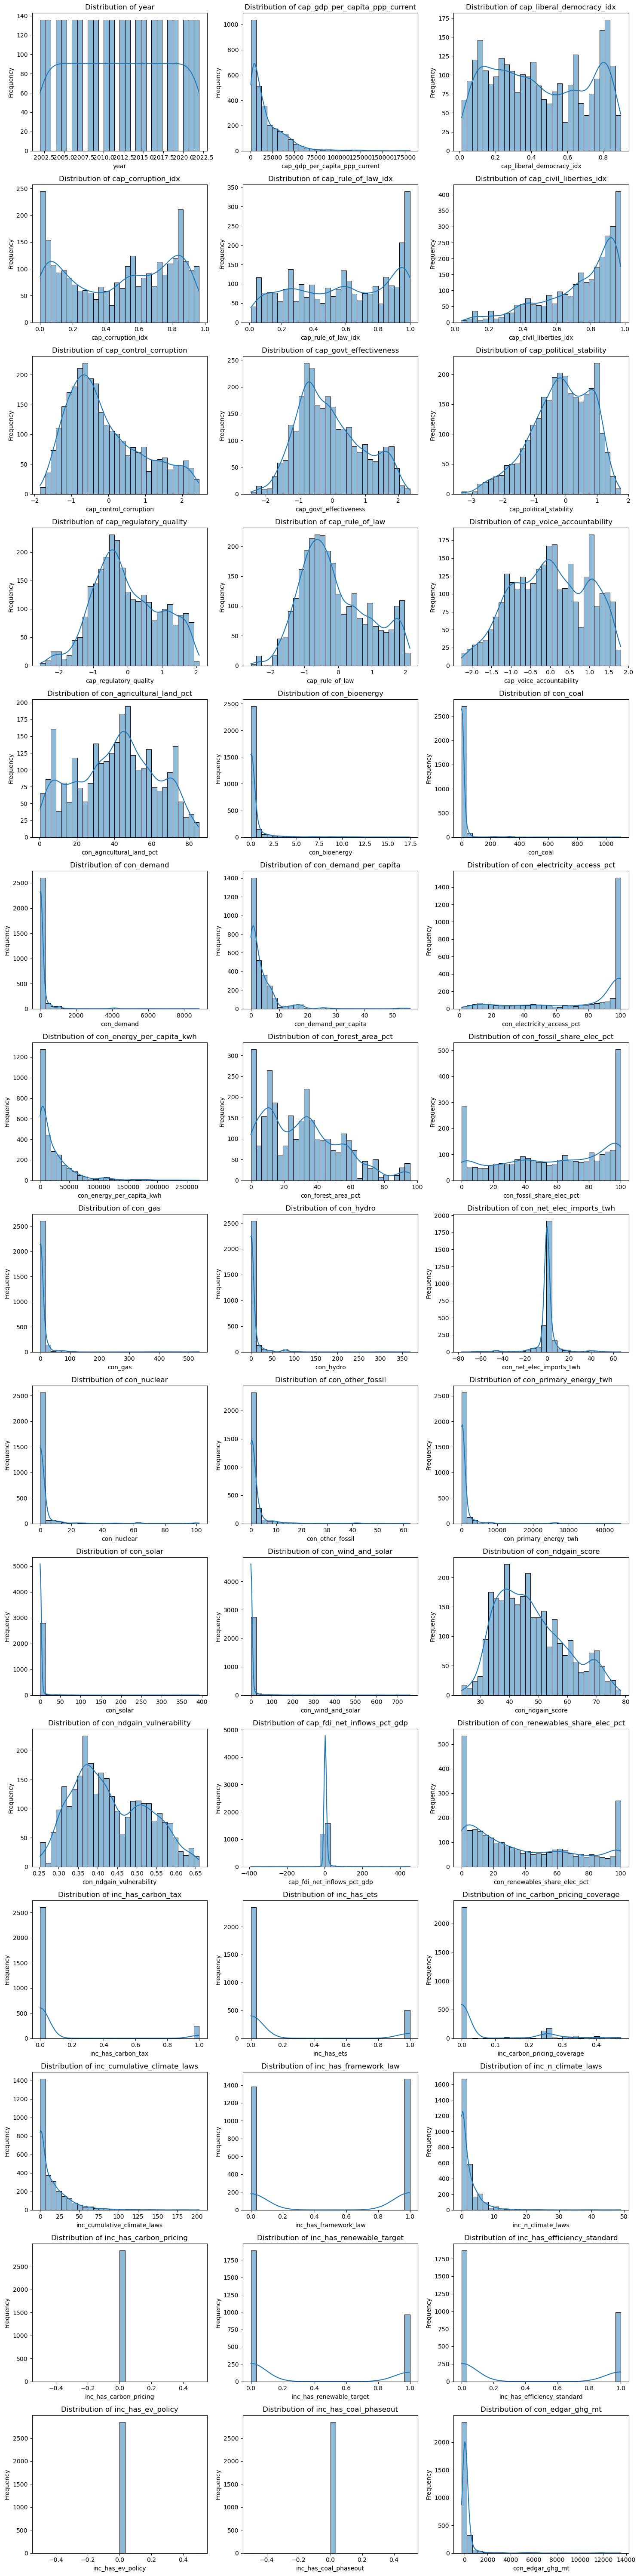

In [16]:
eda_utils.plot_numeric_fields_distributions(df_filtered)

In [17]:
df_filtered.describe()

,year,cap_gdp_per_capita_ppp_current,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_civil_liberties_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,cap_regulatory_quality,...,inc_carbon_pricing_coverage,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout,con_edgar_ghg_mt
count,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,...,2856.000000,2856.000000,2856.000000,2856.000000,2856.0,2856.000000,2856.000000,2856.0,2856.0,2856.000000
mean,2012.000000,17825.876908,0.447432,0.487975,0.575038,0.735454,-0.089537,-0.058090,-0.148709,-0.017408,...,0.057448,14.716737,0.515406,2.184174,0.0,0.337535,0.345588,0.0,0.0,254.871304
std,6.056361,20297.376882,0.262918,0.313468,0.308789,0.218340,1.015271,0.974984,0.951577,0.962821,...,0.120404,21.349578,0.499850,3.496865,0.0,0.472952,0.475643,0.0,0.0,1061.411001
min,2002.000000,492.840755,0.012000,0.002000,0.010000,0.041000,-1.848734,-2.440229,-3.312951,-2.547726,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,-245.407230
25%,2007.000000,3590.244442,0.217000,0.170000,0.300500,0.608000,-0.853330,-0.784158,-0.749497,-0.709759,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,9.912162
50%,2012.000000,10813.936025,0.421000,0.532000,0.592500,0.806000,-0.355056,-0.200911,-0.087762,-0.177335,...,0.000000,7.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.0,0.0,43.210065
75%,2017.000000,25802.122340,0.688000,0.784000,0.871000,0.913000,0.564135,0.596476,0.625529,0.696511,...,0.000000,22.000000,1.000000,3.000000,0.0,1.000000,1.000000,0.0,0.0,123.237151
max,2022.000000,180939.439450,0.897000,0.965000,0.999000,0.976000,2.459118,2.347191,1.753184,2.081799,...,0.473154,203.000000,1.000000,49.000000,0.0,1.000000,1.000000,0.0,0.0,13519.994524


In [18]:
# Identify full o zeros and drop them
zero_cols = df_filtered.columns[(df_filtered == 0).all()]
df_filtered = df_filtered.drop(columns=zero_cols)
print(zero_cols)


Index(['inc_has_carbon_pricing', 'inc_has_ev_policy', 'inc_has_coal_phaseout'], dtype='str')


In [19]:
# Identify binary columns
binary_cols = [
    c for c in df_filtered.columns
    if df_filtered[c].nunique(dropna=True) == 2
]
binary_cols

['inc_has_carbon_tax',
 'inc_has_ets',
 'inc_has_framework_law',
 'inc_has_renewable_target',
 'inc_has_efficiency_standard']

In [20]:
# Identify columns with low variance and with a lot of zeros

def get_zeros_and_variance_check_df(df):
    zeros_and_variance_check = []
    for field in df.select_dtypes(np.number):
        zero_share = (df[field] == 0).mean()
        field_var = df[field].var()

        if field in binary_cols:
            binary_flag = True
        else:
            binary_flag = False


        zeros_and_variance_check.append((field, zero_share, field_var, binary_flag))

    zeros_and_variance_check_df = pd.DataFrame(data=zeros_and_variance_check, columns=["field_name", "field_zero_share", "field_variance", "bianry_flag"])
    return zeros_and_variance_check_df

In [21]:
zeros_and_variance_check_df = get_zeros_and_variance_check_df(df_filtered)

In [22]:
# zeros_and_variance_check_df.to_clipboard(index=False)

In [23]:
skew = df_filtered[[col for col in df_filtered.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew.head(20)

con_solar                         18.100333
con_wind_and_solar                16.703063
con_coal                          10.716587
con_gas                           10.058157
con_hydro                          8.669590
cap_fdi_net_inflows_pct_gdp        8.480725
con_edgar_ghg_mt                   8.449935
con_demand                         8.351667
con_primary_energy_twh             7.524785
con_nuclear                        6.399152
con_other_fossil                   6.160889
con_bioenergy                      5.676543
con_demand_per_capita              4.576735
inc_n_climate_laws                 4.486000
con_energy_per_capita_kwh          2.979298
inc_cumulative_climate_laws        2.726220
cap_gdp_per_capita_ppp_current     2.546681
inc_carbon_pricing_coverage        1.845223
cap_control_corruption             0.719912
con_forest_area_pct                0.669409
dtype: float64

In [24]:
skew.tail(10)

year                          0.000000
con_agricultural_land_pct    -0.079755
cap_voice_accountability     -0.111544
cap_corruption_idx           -0.148069
cap_rule_of_law_idx          -0.172612
con_fossil_share_elec_pct    -0.295079
cap_political_stability      -0.516479
con_net_elec_imports_twh     -0.981781
cap_civil_liberties_idx      -1.038481
con_electricity_access_pct   -1.156544
dtype: float64

In [25]:
highly_skewed_fields = skew[skew.abs() >= 1].index.to_list()
highly_skewed_fields

['con_solar',
 'con_wind_and_solar',
 'con_coal',
 'con_gas',
 'con_hydro',
 'cap_fdi_net_inflows_pct_gdp',
 'con_edgar_ghg_mt',
 'con_demand',
 'con_primary_energy_twh',
 'con_nuclear',
 'con_other_fossil',
 'con_bioenergy',
 'con_demand_per_capita',
 'inc_n_climate_laws',
 'con_energy_per_capita_kwh',
 'inc_cumulative_climate_laws',
 'cap_gdp_per_capita_ppp_current',
 'inc_carbon_pricing_coverage',
 'cap_civil_liberties_idx',
 'con_electricity_access_pct']

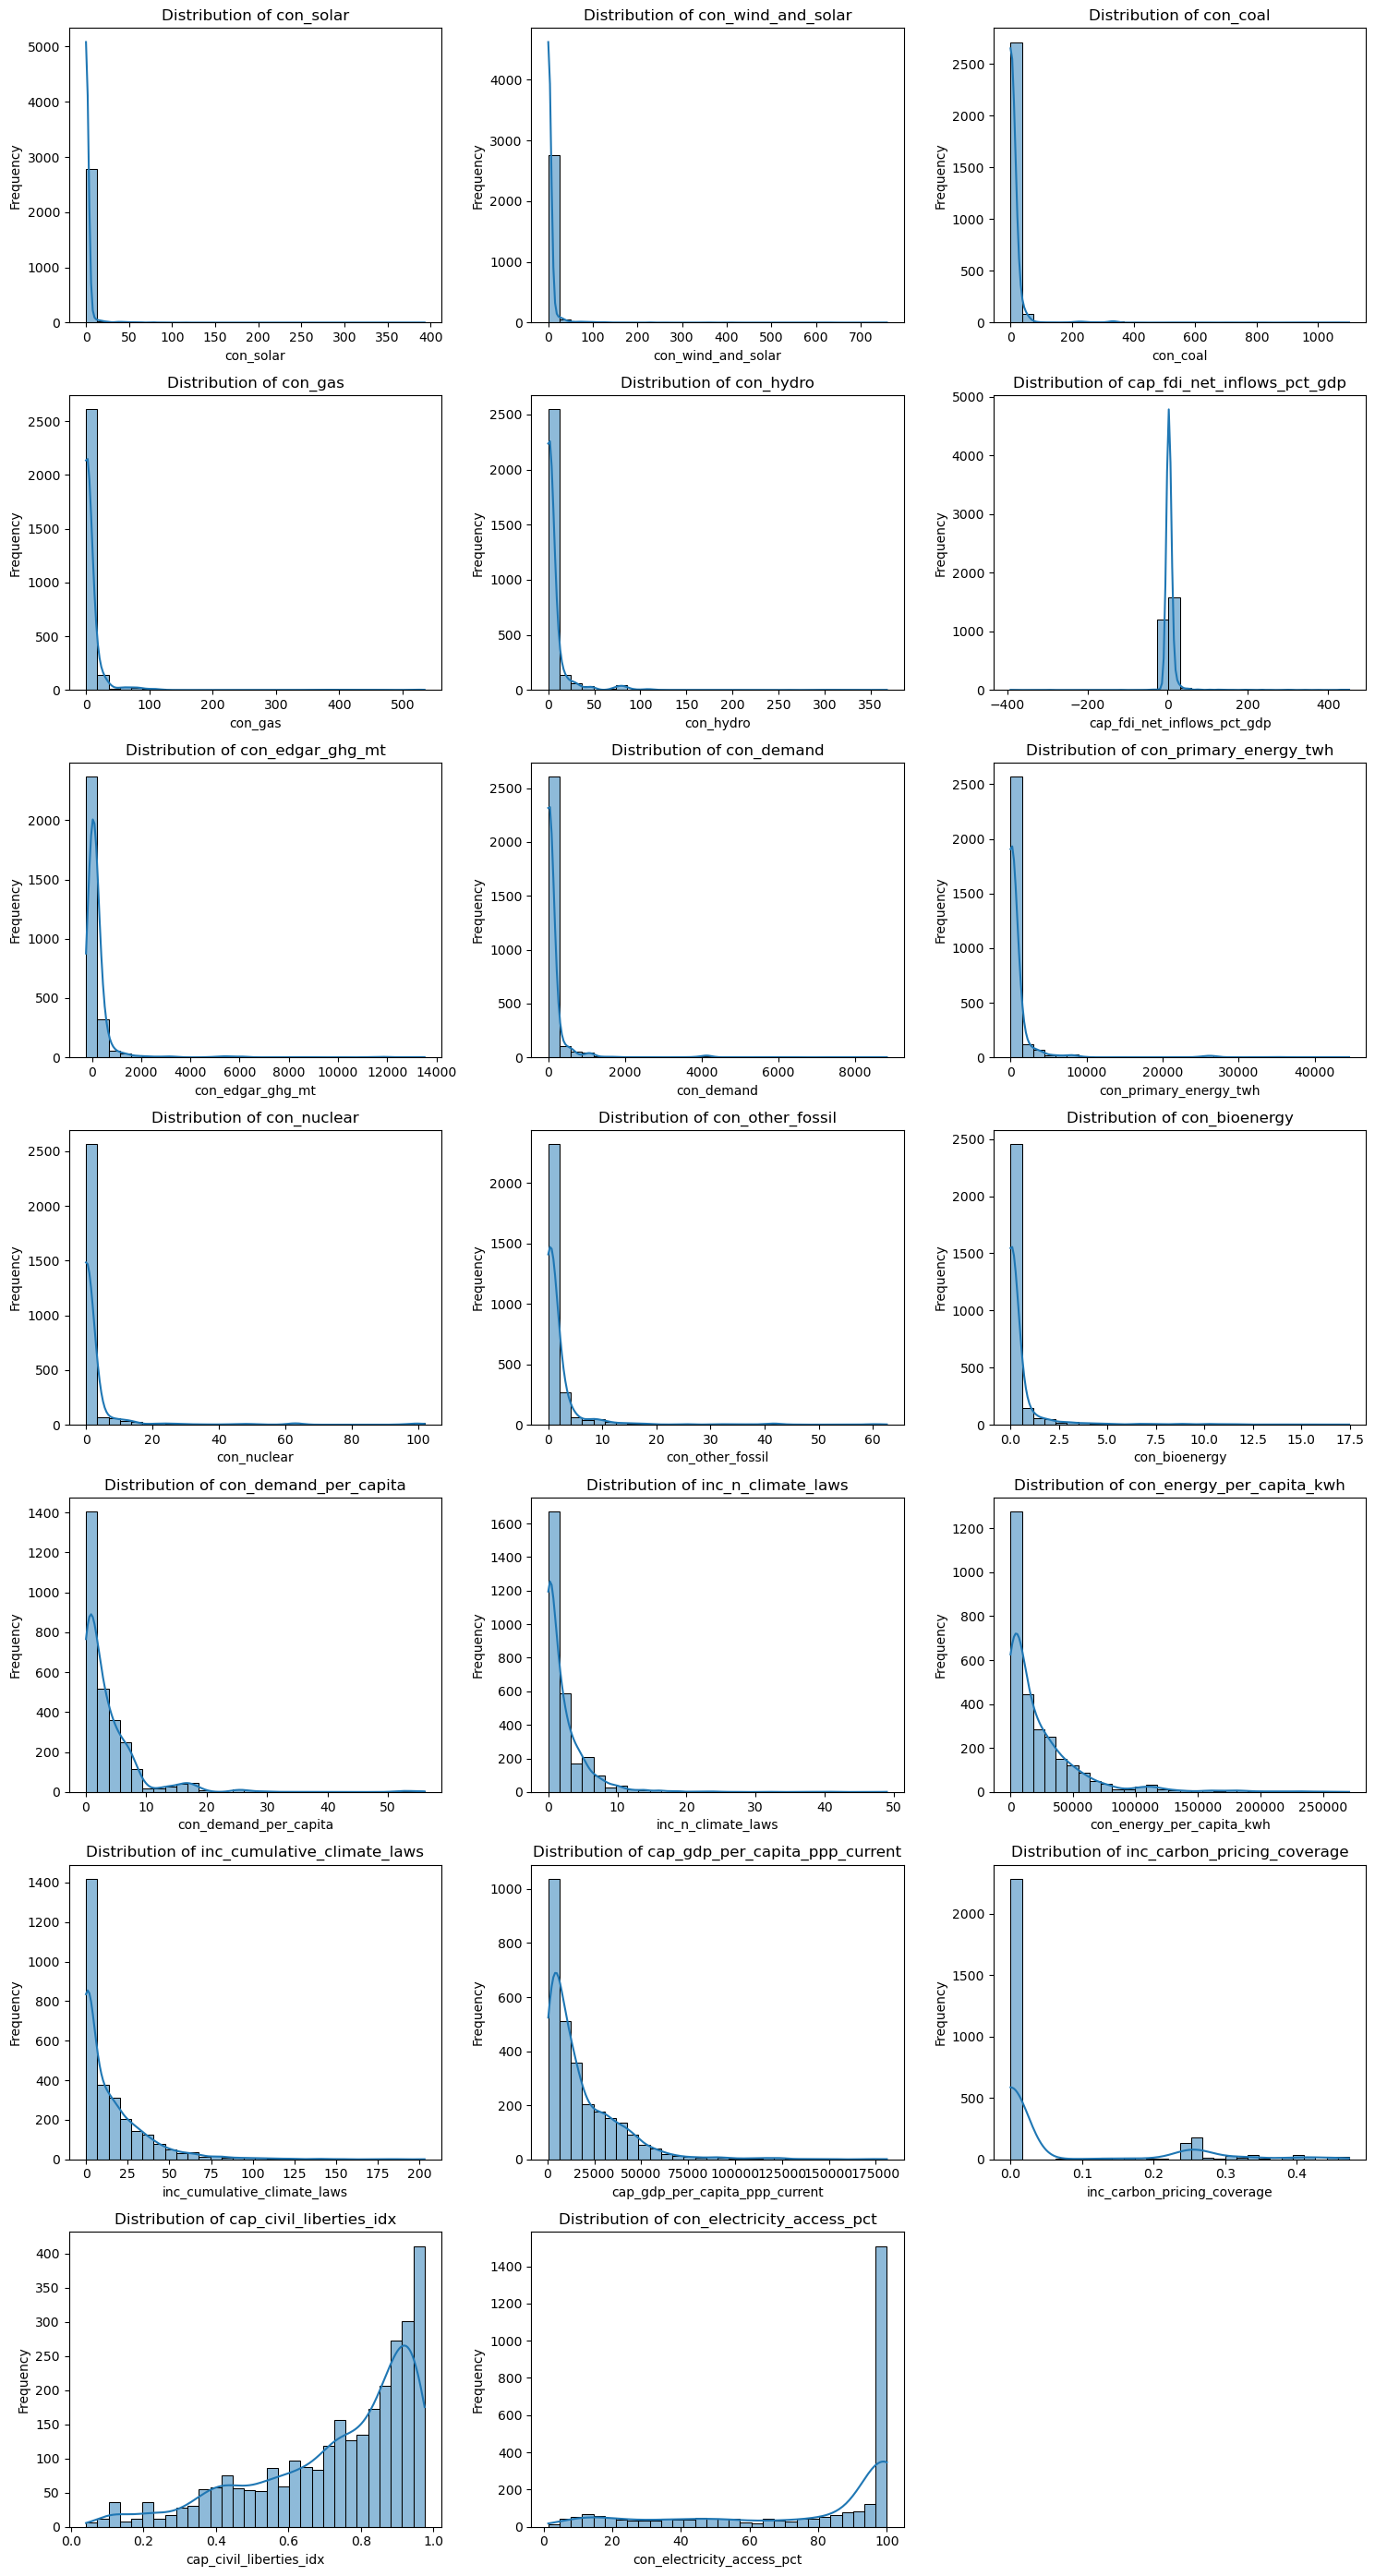

In [26]:
eda_utils.plot_numeric_fields_distributions(df_filtered[highly_skewed_fields])

In [27]:
# Log transform highly skewed fields
for field in highly_skewed_fields:
    df_filtered[f"x_log_signed_{field}"] = np.sign(df_filtered[field]) * np.log1p(np.abs(df_filtered[field]))
df_filtered.head()

,iso_alpha_3,year,cap_gdp_per_capita_ppp_current,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_civil_liberties_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,...,x_log_signed_con_other_fossil,x_log_signed_con_bioenergy,x_log_signed_con_demand_per_capita,x_log_signed_inc_n_climate_laws,x_log_signed_con_energy_per_capita_kwh,x_log_signed_inc_cumulative_climate_laws,x_log_signed_cap_gdp_per_capita_ppp_current,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct
0,AFG,2002,926.507941,0.084,0.919,0.137,0.523,-1.251137,-1.587687,-2.035034,...,0.029559,0.0,0.039221,0.0,5.054301,0.0,6.832501,0.0,0.420682,2.714695
1,AFG,2003,966.962032,0.086,0.919,0.129,0.550,-1.344180,-1.175768,-2.198372,...,0.039221,0.0,0.039221,0.0,5.167969,0.0,6.875193,0.0,0.438255,2.995732
2,AFG,2004,971.633503,0.091,0.931,0.123,0.546,-1.350647,-0.945146,-2.295682,...,0.048790,0.0,0.039221,0.0,5.067381,0.0,6.880007,0.0,0.435671,3.210844
3,AFG,2005,1076.087353,0.113,0.942,0.117,0.542,-1.447252,-1.228816,-2.067510,...,0.048790,0.0,0.039221,0.0,5.330145,0.0,6.982016,0.0,0.433080,3.391147
4,AFG,2006,1121.834471,0.199,0.955,0.116,0.540,-1.446292,-1.473652,-2.219135,...,0.048790,0.0,0.048790,0.0,5.552444,0.0,7.023612,0.0,0.431782,3.540959


In [28]:
df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 63 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   iso_alpha_3                                  2856 non-null   str    
 1   year                                         2856 non-null   int64  
 2   cap_gdp_per_capita_ppp_current               2856 non-null   float64
 3   cap_liberal_democracy_idx                    2856 non-null   float64
 4   cap_corruption_idx                           2856 non-null   float64
 5   cap_rule_of_law_idx                          2856 non-null   float64
 6   cap_civil_liberties_idx                      2856 non-null   float64
 7   cap_control_corruption                       2856 non-null   float64
 8   cap_govt_effectiveness                       2856 non-null   float64
 9   cap_political_stability                      2856 non-null   float64
 10  cap_regulat

In [29]:
# Drop the skewed fields since we have the log transform version
df_log_transformed = df_filtered.drop(columns=highly_skewed_fields)

In [30]:
skew_after_log_transform = df_log_transformed[[col for col in df_log_transformed.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew_after_log_transform.head(20)

x_log_signed_con_solar                      4.072531
x_log_signed_con_bioenergy                  3.204910
x_log_signed_con_wind_and_solar             2.861822
x_log_signed_con_nuclear                    2.769048
x_log_signed_con_coal                       2.328500
x_log_signed_con_other_fossil               1.994020
x_log_signed_inc_carbon_pricing_coverage    1.766301
x_log_signed_con_hydro                      1.589147
x_log_signed_con_gas                        1.486547
cap_control_corruption                      0.719912
con_forest_area_pct                         0.669409
x_log_signed_con_demand                     0.665992
x_log_signed_inc_n_climate_laws             0.635581
con_renewables_share_elec_pct               0.587148
x_log_signed_con_demand_per_capita          0.535643
con_ndgain_score                            0.527854
cap_rule_of_law                             0.454741
cap_govt_effectiveness                      0.389971
x_log_signed_con_primary_energy_twh         0.

In [31]:
zeros_and_variance_check_df_after_transformation = get_zeros_and_variance_check_df(df_log_transformed)
zeros_and_variance_check_df_after_transformation.head()

,field_name,field_zero_share,field_variance,bianry_flag
0,year,0.0,36.679510,False
1,cap_liberal_democracy_idx,0.0,0.069126,False
2,cap_corruption_idx,0.0,0.098262,False
3,cap_rule_of_law_idx,0.0,0.095350,False
4,cap_control_corruption,0.0,1.030776,False


In [32]:
# zeros_and_variance_check_df_after_transformation.to_clipboard()

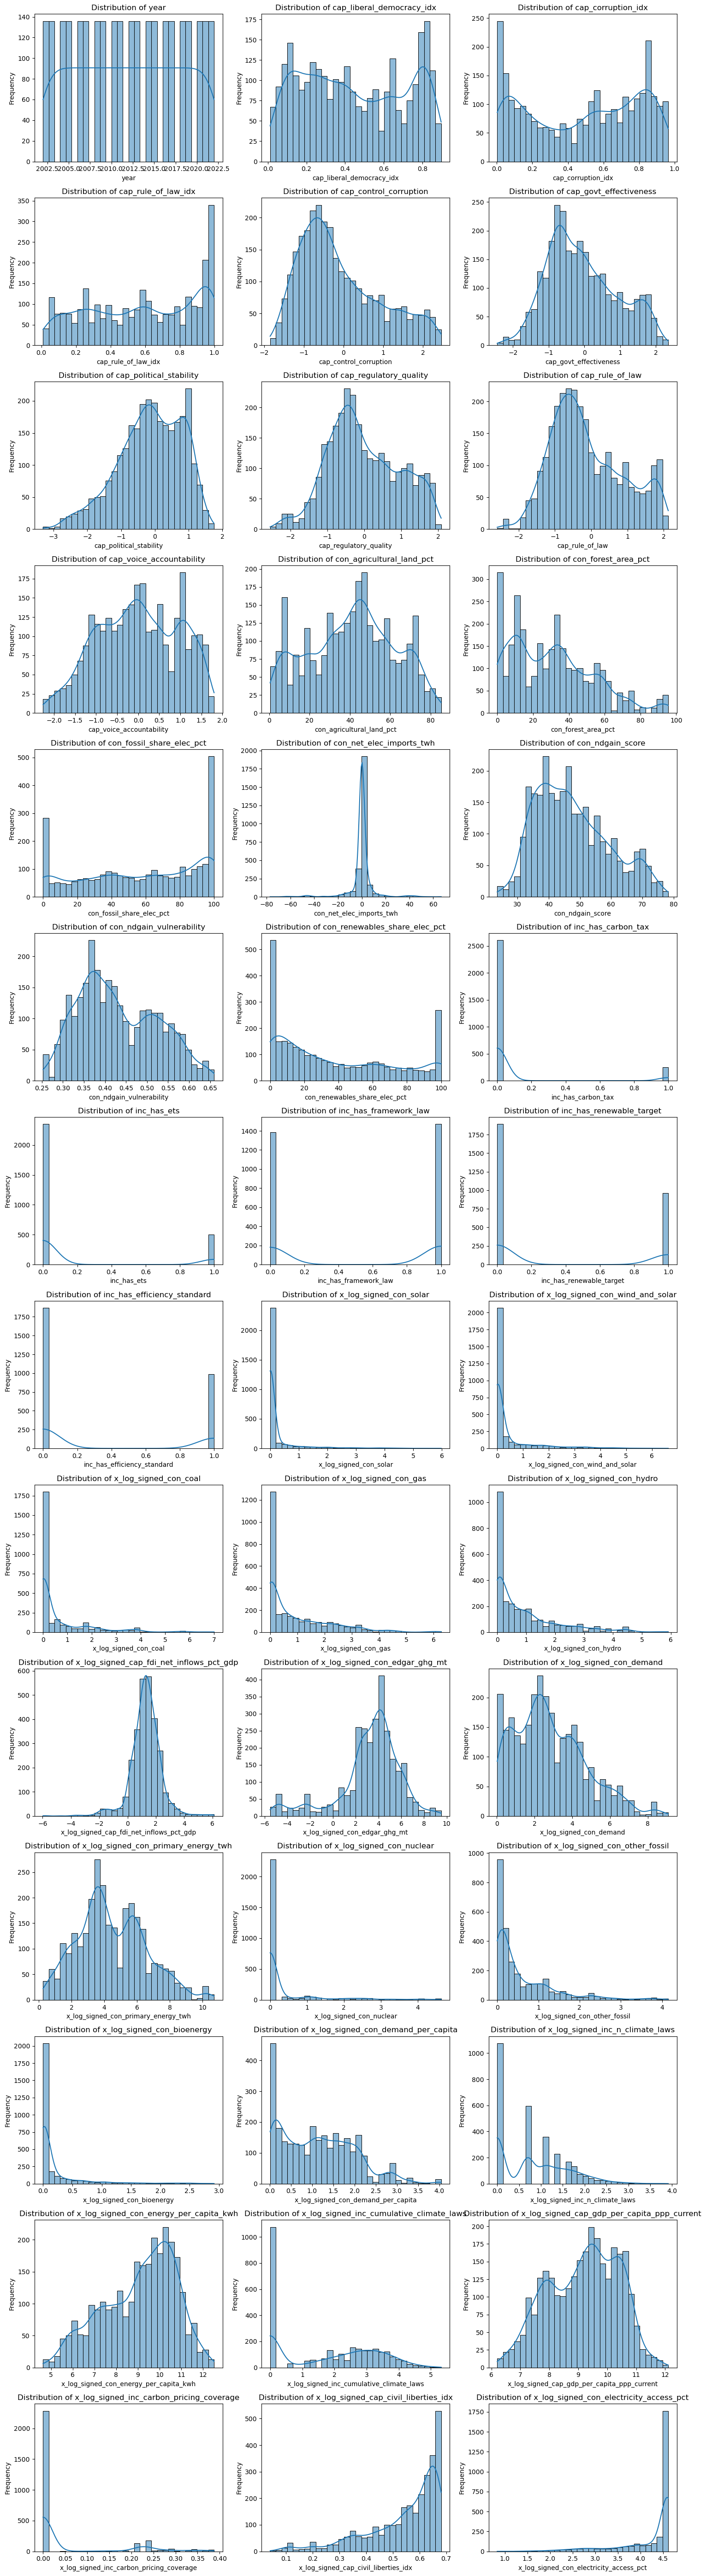

In [33]:
eda_utils.plot_numeric_fields_distributions(df_log_transformed)

In [34]:
df_log_transformed.columns

Index(['iso_alpha_3', 'year', 'cap_liberal_democracy_idx',
       'cap_corruption_idx', 'cap_rule_of_law_idx', 'cap_control_corruption',
       'cap_govt_effectiveness', 'cap_political_stability',
       'cap_regulatory_quality', 'cap_rule_of_law', 'cap_voice_accountability',
       'con_agricultural_land_pct', 'con_forest_area_pct',
       'con_fossil_share_elec_pct', 'con_net_elec_imports_twh',
       'con_ndgain_score', 'con_ndgain_vulnerability',
       'con_renewables_share_elec_pct', 'inc_has_carbon_tax', 'inc_has_ets',
       'inc_has_framework_law', 'inc_has_renewable_target',
       'inc_has_efficiency_standard', 'x_log_signed_con_solar',
       'x_log_signed_con_wind_and_solar', 'x_log_signed_con_coal',
       'x_log_signed_con_gas', 'x_log_signed_con_hydro',
       'x_log_signed_cap_fdi_net_inflows_pct_gdp',
       'x_log_signed_con_edgar_ghg_mt', 'x_log_signed_con_demand',
       'x_log_signed_con_primary_energy_twh', 'x_log_signed_con_nuclear',
       'x_log_signed_con_oth

## ML

In [35]:
training_df = df_log_transformed.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)
training_df.head()

,iso_alpha_3,year,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,cap_regulatory_quality,cap_rule_of_law,...,x_log_signed_con_other_fossil,x_log_signed_con_bioenergy,x_log_signed_con_demand_per_capita,x_log_signed_inc_n_climate_laws,x_log_signed_con_energy_per_capita_kwh,x_log_signed_inc_cumulative_climate_laws,x_log_signed_cap_gdp_per_capita_ppp_current,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct
0,AFG,2002,0.084,0.919,0.137,-1.251137,-1.587687,-2.035034,-1.811546,-1.673473,...,0.029559,0.0,0.039221,0.0,5.054301,0.0,6.832501,0.0,0.420682,2.714695
1,AFG,2003,0.086,0.919,0.129,-1.344180,-1.175768,-2.198372,-1.463108,-1.558294,...,0.039221,0.0,0.039221,0.0,5.167969,0.0,6.875193,0.0,0.438255,2.995732
2,AFG,2004,0.091,0.931,0.123,-1.350647,-0.945146,-2.295682,-1.511549,-1.693925,...,0.048790,0.0,0.039221,0.0,5.067381,0.0,6.880007,0.0,0.435671,3.210844
3,AFG,2005,0.113,0.942,0.117,-1.447252,-1.228816,-2.067510,-1.643440,-1.662966,...,0.048790,0.0,0.039221,0.0,5.330145,0.0,6.982016,0.0,0.433080,3.391147
4,AFG,2006,0.199,0.955,0.116,-1.446292,-1.473652,-2.219135,-1.689469,-1.879005,...,0.048790,0.0,0.048790,0.0,5.552444,0.0,7.023612,0.0,0.431782,3.540959


In [36]:
training_df.year.max()

np.int64(2022)

In [37]:
target_var = "x_log_signed_con_edgar_ghg_mt"

In [38]:
training_df = training_df.sort_values(["iso_alpha_3", "year"]).copy()

# # ================================
# # 1. 1-year lag of emissions (no leakage)
# # ================================

training_df["em_lag_1y"] = (
    training_df
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .shift(1)
)

# ================================
# Helper function to compute slope
# ================================

def compute_slope(series):
    x = np.arange(len(series))
    y = series.values
    return np.polyfit(x, y, 1)[0]


# ================================
# 2. 3-year rolling trend
# ================================

training_df["em_trend_3y"] = (
    training_df
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .rolling(window=3, min_periods=2)
    .apply(compute_slope, raw=False)
    .reset_index(level=0, drop=True)
)

# shift to avoid leakage
training_df["em_trend_3y"] = (
    training_df
    .groupby("iso_alpha_3")["em_trend_3y"]
    .shift(1)
)


# ================================
# 3. 5-year rolling trend
# ================================

training_df["em_trend_5y"] = (
    training_df
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .rolling(window=5, min_periods=3)
    .apply(compute_slope, raw=False)
    .reset_index(level=0, drop=True)
)

# shift to avoid leakage
training_df["em_trend_5y"] = (
    training_df
    .groupby("iso_alpha_3")["em_trend_5y"]
    .shift(1)
)


# ================================
# 4. Trend acceleration
# ================================

training_df["em_acceleration"] = (
    training_df["em_trend_3y"] -
    training_df["em_trend_5y"]
)


# ================================
# 5. Rolling volatility (5y std)
# ================================

training_df["em_volatility_5y"] = (
    training_df
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .rolling(window=5, min_periods=3)
    .std()
    .reset_index(level=0, drop=True)
)

# shift to avoid leakage
training_df["em_volatility_5y"] = (
    training_df
    .groupby("iso_alpha_3")["em_volatility_5y"]
    .shift(1)
)

In [39]:
training_df = training_df.dropna()
training_df

,iso_alpha_3,year,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,cap_regulatory_quality,cap_rule_of_law,...,x_log_signed_inc_cumulative_climate_laws,x_log_signed_cap_gdp_per_capita_ppp_current,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct,em_lag_1y,em_trend_3y,em_trend_5y,em_acceleration,em_volatility_5y
3,AFG,2005,0.113,0.942,0.117,-1.447252,-1.228816,-2.067510,-1.643440,-1.662966,...,0.000000,6.982016,0.0,0.433080,3.391147,3.315615,0.014081,0.014081,0.000000,0.015037
4,AFG,2006,0.199,0.955,0.116,-1.446292,-1.473652,-2.219135,-1.689469,-1.879005,...,0.000000,7.023612,0.0,0.431782,3.540959,3.321104,0.005216,0.010590,-0.005374,0.014799
5,AFG,2007,0.200,0.957,0.112,-1.613251,-1.440111,-2.413373,-1.708872,-1.852560,...,0.693147,7.160807,0.0,0.433080,3.673766,3.328071,0.006228,0.009167,-0.002939,0.015467
6,AFG,2008,0.202,0.957,0.110,-1.672096,-1.527795,-2.691361,-1.607167,-1.903308,...,1.098612,7.196497,0.0,0.433080,3.770459,3.369282,0.024089,0.012967,0.011121,0.023456
7,AFG,2009,0.198,0.957,0.114,-1.552299,-1.507752,-2.711421,-1.664508,-1.876119,...,1.386294,7.359912,0.0,0.435024,3.897924,3.478343,0.075136,0.037363,0.037773,0.068123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,ZWE,2018,0.211,0.762,0.255,-1.246380,-1.297955,-0.721012,-1.525652,-1.293059,...,2.772589,8.292521,0.0,0.347836,3.837299,3.744684,-0.027798,-0.018262,-0.009536,0.032955
2852,ZWE,2019,0.197,0.765,0.227,-1.290334,-1.310435,-0.943303,-1.486515,-1.311041,...,2.995732,8.334845,0.0,0.330742,3.864931,3.790427,0.016512,-0.002733,0.019245,0.022915
2853,ZWE,2020,0.192,0.795,0.233,-1.308788,-1.342368,-1.052743,-1.434415,-1.337362,...,3.295837,8.337967,0.0,0.347836,3.983413,3.754520,0.004918,-0.005849,0.010768,0.024351
2854,ZWE,2021,0.188,0.826,0.215,-1.277147,-1.290561,-0.954443,-1.386109,-1.282122,...,3.367296,8.482206,0.0,0.329304,3.912023,3.714499,-0.037964,-0.007597,-0.030367,0.027256


In [40]:
features_list = training_df.columns[
    ~training_df.columns.isin(["iso_alpha_3", "year", target_var])
].tolist()

features_list

['cap_liberal_democracy_idx',
 'cap_corruption_idx',
 'cap_rule_of_law_idx',
 'cap_control_corruption',
 'cap_govt_effectiveness',
 'cap_political_stability',
 'cap_regulatory_quality',
 'cap_rule_of_law',
 'cap_voice_accountability',
 'con_agricultural_land_pct',
 'con_forest_area_pct',
 'con_fossil_share_elec_pct',
 'con_net_elec_imports_twh',
 'con_ndgain_score',
 'con_ndgain_vulnerability',
 'con_renewables_share_elec_pct',
 'inc_has_carbon_tax',
 'inc_has_ets',
 'inc_has_framework_law',
 'inc_has_renewable_target',
 'inc_has_efficiency_standard',
 'x_log_signed_con_solar',
 'x_log_signed_con_wind_and_solar',
 'x_log_signed_con_coal',
 'x_log_signed_con_gas',
 'x_log_signed_con_hydro',
 'x_log_signed_cap_fdi_net_inflows_pct_gdp',
 'x_log_signed_con_demand',
 'x_log_signed_con_primary_energy_twh',
 'x_log_signed_con_nuclear',
 'x_log_signed_con_other_fossil',
 'x_log_signed_con_bioenergy',
 'x_log_signed_con_demand_per_capita',
 'x_log_signed_inc_n_climate_laws',
 'x_log_signed_con_

In [42]:
print("Running regression without group feature...")

enet_params = dict(
    l1_ratio=[0.01],
    n_alphas=300,          # wider alpha search
    eps=1e-4,              # allow smaller alphas
    cv=7,
    max_iter=30000,
    n_jobs=1,
    random_state=42,
)


ra_4 = RegressionAnalysis(
    df=training_df,
    target_col=target_var,
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=5,
    scaler_type="standard",
    feature_cols=features_list,
    include_year=False,
    enet_params=enet_params
)

ra_4.cross_validate()
ra_4.fit()
ra_4.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/home/tony/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/home/tony/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/home/tony/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_mode

ElasticNet            0.1229          nan
RandomForest          0.0854       0.1384
XGBoost               0.1326       0.2863
Median                1.9109       1.9718


/home/tony/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.1154         0.1034            0.2003            0.1493               18.15               23.47
RandomForest            0.0282         0.0754            0.0710            0.1326                4.38               25.58
XGBoost                 0.0192         0.1211            0.0252            0.1991                3.73               39.46
Median                  1.9243         1.8946            2.8024            2.7669              246.45              273.59


{'ElasticNet': {'train_mae_log': 0.11540752041302207,
  'test_mae_log': 0.10341911771276449,
  'train_rmse_log': 0.2002506464299106,
  'test_rmse_log': 0.14929291768868977,
  'train_mae_level': np.float64(18.15237687066029),
  'test_mae_level': np.float64(23.470488922843533)},
 'RandomForest': {'train_mae_log': 0.02816800543255405,
  'test_mae_log': 0.07540994254798473,
  'train_rmse_log': 0.07103260408714553,
  'test_rmse_log': 0.1326013945374349,
  'train_mae_level': np.float64(4.3847197622237),
  'test_mae_level': np.float64(25.580080620975263)},
 'XGBoost': {'train_mae_log': 0.019247116441746107,
  'test_mae_log': 0.12105774473185654,
  'train_rmse_log': 0.025193673436964766,
  'test_rmse_log': 0.19910393170067175,
  'train_mae_level': np.float64(3.72920012554128),
  'test_mae_level': np.float64(39.45542715562539)},
 'Median': {'train_mae_log': 1.9243335561016925,
  'test_mae_log': 1.8945824518339203,
  'train_rmse_log': 2.802425746498206,
  'test_rmse_log': 2.766893073092513,
  't

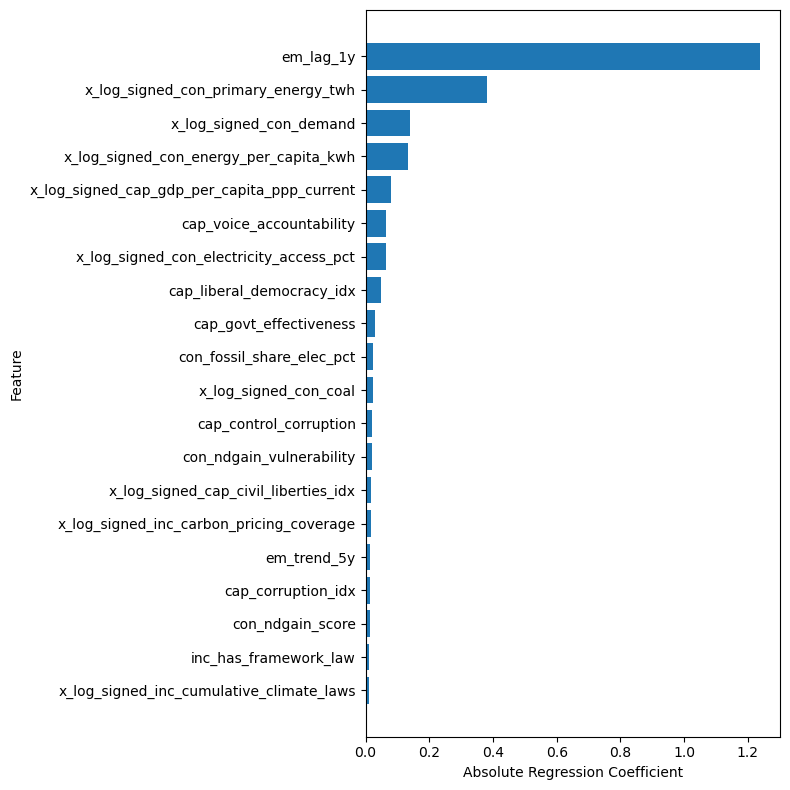

In [41]:
ra_4.plot_top_enet_regressors()

In [43]:
# one model
ra_4.get_model_hyperparameters("ElasticNet")

{'ElasticNet': {'is_fitted': True,
  'hyperparameters': {'alphas': 'warn',
   'copy_X': True,
   'cv': TimeSeriesSplit(gap=0, max_train_size=None, n_splits=7, test_size=None),
   'eps': 0.0001,
   'fit_intercept': True,
   'l1_ratio': [0.01],
   'max_iter': 30000,
   'n_alphas': 300,
   'n_jobs': 1,
   'positive': False,
   'precompute': 'auto',
   'random_state': 42,
   'selection': 'cyclic',
   'tol': 0.0001,
   'verbose': 0},
  'selected_alpha': 0.02743927592937298,
  'selected_l1_ratio': 0.01,
  'n_iter': 156}}

In [44]:
# df_l1 = ra_4.enet_l1_ratio_experiment(
#     l1_ratios=[0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
#     plot=True,
# )
# df_l1